In [1]:
import os

if 'main_dir' in globals():
    os.chdir(main_dir)

import pandas as pd
from utils.load_config import load_exp_config, get_value_from_fields, get_df_historical_data
from utils.load_data import (
    get_df_from_datetime_range,
    get_mlruns_info
    )
import numpy as np

# %matplotlib inline

if os.getcwd().endswith("notebooks"):
    main_dir = os.getcwd()
    os.chdir("..")

In [2]:
os.getuid()

1000

In [ ]:
DECAY_RATE = 1

start_datetime_str = "2024-11-04 15-18-27"
end_datetime_str = "2024-11-05 08-00-00"

# end_datetime_str = start_datetime_str = "2024-11-04 14-38-04"
# end_datetime_str = start_datetime_str = "2024-10-31 13-46-21"
# end_datetime_str = start_datetime_str = "2024-11-06 11-00-44" # Error of unchanged observation
# end_datetime_str = start_datetime_str = "2024-11-06 12-08-58"

# contain large buffer and reset buffer [true, false]
start_datetime_str = "2024-11-06 12-08-58"
end_datetime_str = "2024-11-06 13-27-35"

# contain large buffer and reset buffer [true, false] with bugfix on robot pursuit
start_datetime_str = "2024-11-07 08-38-32"
end_datetime_str = "2024-11-07 10-41-32"

# end_datetime_str = start_datetime_str = "2024-11-07 11-31-51"
end_datetime_str = start_datetime_str = "2024-11-09 14-13-27"

# Full run at server
start_datetime_str = "2024-11-07 14-35-44"
end_datetime_str = "2024-11-08 04-58-17"

# Test
end_datetime_str = start_datetime_str = "2024-11-08 21-30-23"
end_datetime_str = start_datetime_str = "2024-11-10 22-47-07"
end_datetime_str = start_datetime_str = "2024-11-11 07-38-36"
# end_datetime_str = start_datetime_str = "2024-11-09 20-42-20"


# end_datetime_str = start_datetime_str = "2024-11-08 21-30-23"

# end_datetime_str = start_datetime_str = "2024-11-10 14-18-31"
# end_datetime_str = start_datetime_str = "2024-11-10 16-46-24"


# Full SAC run at server
# start_datetime_str = "2024-11-08 22-32-12"
# end_datetime_str = "2024-11-09 06-05-21"

# SAC with Pushing Object
end_datetime_str = start_datetime_str = "2024-11-11 09-14-40"
end_datetime_str = start_datetime_str = "2024-11-11 11-23-51"

# SAC Line Following on Server
end_datetime_str = start_datetime_str = "2024-11-11 11-51-46"
end_datetime_str = start_datetime_str = "2024-11-11 13-44-04"
end_datetime_str = start_datetime_str = "2024-11-11 14-26-45"

end_datetime_str = start_datetime_str = "2024-11-09 22-07-25"
end_datetime_str = start_datetime_str = "2024-11-12 08-41-57"
end_datetime_str = start_datetime_str = "2024-11-12 11-10-15"

# SAC Line Following on PC
end_datetime_str = start_datetime_str = "2024-11-12 13-17-48"
# Eval
end_datetime_str = start_datetime_str = "2024-11-12 15-35-48"

# # SAC Robot Pursuit on Server
# end_datetime_str = start_datetime_str = "2024-11-12 16-09-49"
# end_datetime_str = start_datetime_str = "2024-11-12 20-07-22"

# # SAC Pushing Object on PC
# end_datetime_str = start_datetime_str = "2024-11-11 19-06-15"
# end_datetime_str = start_datetime_str = "2024-11-11 22-49-30"

# end_datetime_str = "2024-11-13 00-52-41"
# start_datetime_str = "2024-11-12 22-14-24"

# SAC Line Following
end_datetime_str = start_datetime_str = "2024-11-13 10-42-03"

# Only used for pivot table
end_datetime_str = start_datetime_str = "2024-11-13 17-38-28" # Laptop
# end_datetime_str = start_datetime_str = "2024-11-13 18-25-28" # Server
end_datetime_str = start_datetime_str = "2024-11-13 19-10-58" # Azure2
single_load = True

if single_load:
    df = get_df_from_datetime_range(start_datetime_str, 
                                    end_datetime_str, 
                                    decay_rate=DECAY_RATE,
                                    max_iter=np.inf,
                                    validity_check=False,
                                    reload=True,
                                    # backup_dir="/media/tcc/F89F-5CC1/ICLR/backup-data"
                                    )
    
    if start_datetime_str == end_datetime_str:
        actor_df = get_mlruns_info(start_datetime_str, 
                                    end_datetime_str,
                                    reload=True,)
        actor_df["experiment_path"] = df.experiment_path.unique()[0]
else:
    chosen = "train"
    if chosen == "eval":
        # only load eval
        files = [
            "2024-11-12 15-35-48", # Line Following large
            "2024-11-13 10-42-03", # Line Following small

            "2024-11-13 07-42-39", # Robot Pursuit large
            "2024-11-12 22-09-50", # Robot Pursuit small

            "2024-11-13 01-42-56", # Pushing Object small
            
        ]
    else:
        # only load train
        files = [
            "2024-11-12 13-17-48", # Line Following large
            "2024-11-13 10-42-03", # Line Following small

            "2024-11-12 20-07-22", # Robot Pursuit large
            "2024-11-12 22-09-50", # Robot Pursuit small

            "2024-11-13 01-42-56", # Pushing Object small
        ]

    final_df = None
    final_actor_dfs = None
    for time_n in files:
        end_datetime_str = start_datetime_str = time_n
        df = get_df_from_datetime_range(start_datetime_str, 
                                    end_datetime_str, 
                                    decay_rate=DECAY_RATE,
                                    max_iter=np.inf,
                                    validity_check=False,
                                    reload=False,
                                    backup_dir="/media/tcc/F89F-5CC1/ICLR/backup-data"
                                    )
        actor_df = get_mlruns_info(start_datetime_str, 
                                    end_datetime_str)
        actor_df["experiment_path"] = df.experiment_path.unique()[0]

        if final_df is None:
            final_df = df.copy()
            final_actor_dfs = actor_df.copy()

        else:
            final_df = pd.concat([final_df, df])
            final_actor_dfs = pd.concat([final_actor_dfs, actor_df])
    
    df = final_df
    actor_df = final_actor_dfs
# end_datetime_str = start_datetime_str = "2024-11-11 09-14-40"
# df_2 = get_df_from_datetime_range(start_datetime_str, 
#                                 end_datetime_str, 
#                                 decay_rate=DECAY_RATE,
#                                 max_iter=np.inf,
#                                 validity_check=False,
#                                 reload=False
#                                 )

# df = pd.concat([df, df_2])

# df.head()
actor_df.head()

Load path: /home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2024-11-13/18-25-28


,time,actor_loss,step_id,run_name,experiment_path
0,1731522411663,-0.114363,300,2024-11-13 18-25-28 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
1,1731522445882,-0.162646,400,2024-11-13 18-25-28 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
2,1731522480748,-0.206890,500,2024-11-13 18-25-28 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
3,1731522515775,-0.216766,600,2024-11-13 18-25-28 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
4,1731522551125,-0.274493,700,2024-11-13 18-25-28 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...


In [4]:
exp_config = df.exp_config.values[0]
df = df.reindex()
def extract_columns(row):
    scenario = row.exp_config["scenario"]["_target_"].split(".")[-1]
    is_reset_buffer = row.exp_config["scenario"]["reset_rb_each_task"]
    buffer_size = row.exp_config["scenario"]["buffer_size"]
    learning_starts = row.exp_config["scenario"]["learning_starts"]
    controller = "SAC" if "sac" in scenario.lower() else "TD3"
    category = scenario[:scenario.find(controller)]
    return category, controller, is_reset_buffer, buffer_size, learning_starts
    
    # return pd.Series(data=[category, controller, is_reset_buffer, buffer_size], 
    #                  index=["category", "controller", "is_reset_buffer", "buffer_size"])

tmp = df.apply(extract_columns, axis=1, result_type='expand')
# tmp = df.exp_config.apply(extract_columns)
tmp.columns = ["category", "controller", "is_reset_buffer", "buffer_size", "learning_starts"]
df = pd.concat([df, tmp], axis=1)

df = df.sort_values(["iteration_id", "step_id"])
df["trained_task"] = df.apply(lambda row: row.task_name if row.phase == "train" else pd.NA, axis=1)
df["trained_task"] = df.trained_task.fillna(method='ffill')

/tmp/ipykernel_8420/2722885736.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["trained_task"] = df.trained_task.fillna(method='ffill')


In [5]:
[c for c in df.columns if "pos" in c]

['robot_position']

In [6]:
pd.Series(tmp.iloc[0], index=["category", "controller", "is_reset_buffer", "buffer_size"])

category           RobotPursuit
controller                  SAC
is_reset_buffer           False
buffer_size               20000
Name: 0, dtype: object

In [7]:
############################### Robot Pursuit is misisng ###############################
# group_df = df.groupby(["controller", "category", "task_name", "is_reset_buffer"]).last()
group_df = df.groupby(["controller", "category", "buffer_size"]).last()
group_df

,,,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,exploration,...,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path,is_reset_buffer,learning_starts,trained_task
controller,category,buffer_size,,,,,,,,,,,,,,,,,,,,,
SAC,RobotPursuit,20000,2.211,10.0,None,19.506556,1,2351,yellow_cylinder,465,eval,False,...,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,False,250,yellow_cylinder


In [8]:
group_df.index.names, group_df.index[0]

(FrozenList(['controller', 'category', 'buffer_size']),
 ('SAC', 'RobotPursuit', 20000))

In [9]:
"\t".join([f"{a}:{b}" for a, b in list(zip(group_df.index.names, group_df.index[0]))])
# list(zip(group_df.index.names, group_df.index[0]))
group_df.index

MultiIndex([('SAC', 'RobotPursuit', 20000)],
           names=['controller', 'category', 'buffer_size'])

In [10]:
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index[0]]

In [11]:
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvelica']})
# for Palatino and other serif fonts use:
# rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=False)

In [12]:
import matplotlib
print(matplotlib.matplotlib_fname())
matplotlib.__version__

/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/venv/lib/python3.11/site-packages/matplotlib/mpl-data/matplotlibrc


'3.9.2'

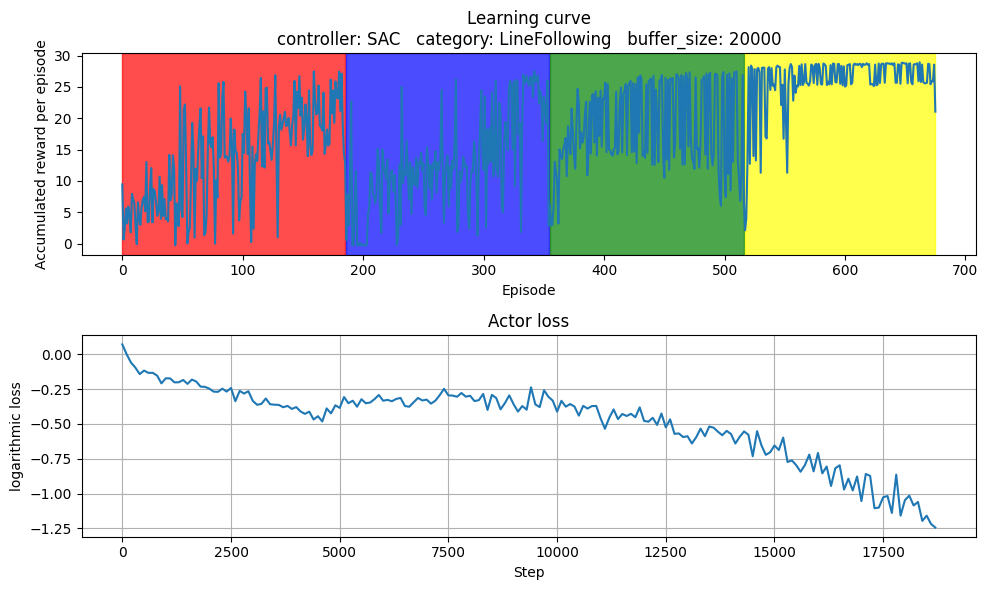

In [71]:
import matplotlib.pyplot as plt
# import matplotlib
# %matplotlib inline

def plot_learning_curve(index, index_names, df, title="Learning curve", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,3))

    df = df.reset_index().set_index(index_names)
    tmp_df = df.loc[index]

    # Filter exploration actions
    tmp_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "learning_starts", "phase"]]
    tmp_df = tmp_df[np.invert(np.logical_and(tmp_df.phase == "train", tmp_df.step_id <= tmp_df.learning_starts))]
    tmp_group_df = tmp_df.groupby("iteration_id")

    tmp_group_df = tmp_group_df.aggregate({
        "current_undiscounted_value": "last", 
        "task_name": "last",
        "step_id": "last"
        })
    
    # Re-assign index for ploting
    tmp_group_df = tmp_group_df.reset_index()
    tmp_group_df.iteration_id = tmp_group_df.reset_index().index
    tmp_group_df = tmp_group_df.set_index("iteration_id")

    tmp_group_df.plot(y="current_undiscounted_value", ax=ax)

    colors = ["red", "blue", "green", "yellow"]
    for t in tmp_group_df.task_name.unique():
        for c in colors:
            if c in t.lower():
                break

        tmp = tmp_group_df.reset_index().set_index("task_name").loc[t]
        ax.axvspan(tmp.iteration_id.values[0], tmp.iteration_id.values[-1], alpha=0.7, color=c)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Accumulated reward per episode')
    ax.set_title(
        f'{title}\n' + 
        "   ".join([f"{a}: {b}" for a, b in list(zip(index_names, index))])
    )
    legend = ax.legend()
    legend.remove()


for id in group_df.index:
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    plot_learning_curve(id, group_df.index.names, df[df.phase=="train"], ax=ax[0])
    actor_df["steps"] = [100 * i for i in range(len(actor_df))]
    actor_df[actor_df.experiment_path == df.experiment_path.values[0]].plot(x="steps", y="actor_loss", ax=ax[1])
    ax[1].set_title("Actor loss")
    ax[1].set_ylabel("logarithmic loss")
    ax[1].set_xlabel("Step")
    ax[1].legend().remove()
    ax[1].grid()
# plot_learning_curve(group_df.index[1], group_df.index.names, df)
# plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)
# plot_learning_curve(('TD3', 'LineFollowing', False), group_df.index.names, df)
# plt.show()
plt.tight_layout()

In [14]:
df = df.reset_index()
df[df.iteration_id==1]

,controller,category,buffer_size,index,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,...,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path,is_reset_buffer,learning_starts,trained_task
0,SAC,RobotPursuit,20000,0,0.000,0.50,None,0.50,1,1,...,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,False,250,red_cube
1,SAC,RobotPursuit,20000,1,0.000,0.00,None,0.50,1,1,...,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,False,250,red_cube
2,SAC,RobotPursuit,20000,2,0.198,0.00,None,0.50,1,1,...,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,False,250,red_cube
3,SAC,RobotPursuit,20000,3,0.363,0.15,None,0.65,1,1,...,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,False,250,red_cube
4,SAC,RobotPursuit,20000,4,0.528,0.00,None,0.65,1,1,...,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,False,250,red_cube
5,SAC,RobotPursuit,20000,5,0.693,-1.00,None,-0.35,1,1,...,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,False,250,red_cube


In [15]:
df.running_objective.describe()

count    24348.000000
mean         0.865306
std          1.978711
min         -1.000000
25%          0.325000
50%          0.550000
75%          0.750000
max         10.000000
Name: running_objective, dtype: float64

In [16]:
def postprocess_linefollowing(df):
    if not df.index.is_integer():
        df = df.reset_index()

    df["catch_the_line"] = df.running_objective.apply(lambda x: x > 0.7)
    return df

In [17]:
df = postprocess_linefollowing(df)

analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

if "catch_the_line" in df.columns:
    agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
    agg['catch_the_line'] = 'sum'

    analyse_group_df = analyse_group_df.agg(agg)
else:
    analyse_group_df = analyse_group_df.last()

analyse_group_df

/tmp/ipykernel_8420/3626384526.py:2: FutureWarning: RangeIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if not df.index.is_integer():


Angular Velocity [rad/s]  Image pixel 0  \
task_name       iteration_id                                            
blue_sphere     1869                        -15.965378       0.219608   
                1870                         15.918403       0.854902   
                1871                         15.986856       0.854902   
                1872                        -15.639508       0.274510   
                1873                          4.718510       0.854902   
...                                                ...            ...   
yellow_cylinder 2347                         13.181025       0.854902   
                2348                        -12.075295       0.862745   
                2349                          9.604338       0.858824   
                2350                         15.939980       0.854902   
                2351                          1.733561       0.854902   

                              Image pixel 1  Image pixel 10  Image pixel 100  \
task_name       iteration_id                                                   
blue_sphere     1869               0.219608        0.211765         0.149020   
                1870               0.854902        0.854902         0.231373   
                1871               0.854902        0.854902         0.262745   
                1872               0.274510        0.266667         0.215686   
                1873               0.854902        0.854902         0.286275   
...                                     ...             ...              ...   
yellow_cylinder 2347               0.854902        0.862745         0.713726   
                2348               0.862745        0.847059         0.854902   
                2349               0.858824        0.858824         0.694118   
                2350               0.854902        0.858824         0.772549   
                2351               0.854902        0.854902         0.811765   

                              Image pixel 1000  Image pixel 1001  \
task_name       iteration_id                                       
blue_sphere     1869                  0.290196          0.290196   
                1870                  0.290196          0.290196   
                1871                  0.290196          0.290196   
                1872                  0.290196          0.290196   
                1873                  0.290196          0.290196   
...                                        ...               ...   
yellow_cylinder 2347                  0.290196          0.290196   
                2348                  0.290196          0.290196   
                2349                  0.290196          0.290196   
                2350                  0.290196          0.290196   
                2351                  0.290196          0.290196   

                              Image pixel 1002  Image pixel 1003  \
task_name       iteration_id                                       
blue_sphere     1869                  0.294118          0.294118   
                1870                  0.290196          0.290196   
                1871                  0.290196          0.290196   
                1872                  0.290196          0.290196   
                1873                  0.290196          0.290196   
...                                        ...               ...   
yellow_cylinder 2347                  0.290196          0.290196   
                2348                  0.290196          0.290196   
                2349                  0.290196          0.290196   
                2350                  0.290196          0.290196   
                2351                  0.290196          0.290196   

                              Image pixel 1004  ...  index  is_reset_buffer  \
task_name       iteration_id                    ...                           
blue_sphere     1869                  0.294118  ...     14            False   
                1870            

# Evaluation

In [18]:
def experiment_sort_index(index):
    print(index)
    if index.name == "category":
        category_list = ["PushingObject", "LineFollowing", "RobotPursuit"]
    #     return [category_list.index(n) for n in index]nt(index)
    # if index.name == "category":
    #     category_list = ["PushingObject", "LineFollowing", "RobotPursuit"]
    #     return [category_list.index(n) for n in index]
    
    if index.name in ["trained_task", "task_name"]:
        lf_list = ["circle_red", "circle_blue", "circle_green", "circle_yellow"]
        rp_list = ["red_cube", "green_capsule", "blue_sphere", "yellow_cylinder"]

        common_list = lf_list + rp_list
        return [common_list.index(n) for n in index]
    
    return [1 for _  in index]

In [19]:
df = postprocess_linefollowing(df)

if "eval" in df.phase.unique():
    analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

    if "catch_the_line" in df.columns:
        agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
        agg['catch_the_line'] = 'sum'

        analyse_group_df = analyse_group_df.agg(agg)
    else:
        analyse_group_df = analyse_group_df.last()

    def is_solved_task(row):
        if row.category == "LineFollowing":
            return row.catch_the_line > 20

        if row.category == "PushingObject":
            if row.task_name in ["blue", "yellow"]:
                return row.running_objective == 10
            
            if row.task_name in ["red", "green"]:
                return row.running_objective != -10

        if row.category == "RobotPursuit":
            return row.running_objective == 10
        
        return False

    def aggregate_function(series):
        sucess = np.sum(series)
        total = series.count()
        return "{:02.0f} / {:02.0f} = {:03.2f}".format(sucess, total, np.round(sucess / total, 2))

    analyse_group_df = analyse_group_df.reset_index()
    analyse_group_df["completion"] = analyse_group_df.apply(is_solved_task, axis=1)

    analyse_group_df.buffer_size = analyse_group_df.buffer_size.apply(lambda x: 20000 if x == 25000 else x)
    # analyse_group_df = analyse_group_df.set_index(['controller', 'category', 'buffer_size'])

    pivot_table = pd.pivot_table(
        analyse_group_df.reset_index(), 
        columns=['controller', 'buffer_size', 'trained_task'],
        index=["category", "task_name"], 
        values="completion", aggfunc=aggregate_function
    )
    
else:
    pivot_table = None

pivot_table
pivot_table.sort_index(key=experiment_sort_index, ascending=True).sort_index(key=experiment_sort_index, axis=1, ascending=True)

/tmp/ipykernel_8420/3626384526.py:2: FutureWarning: RangeIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if not df.index.is_integer():


Index(['RobotPursuit', 'RobotPursuit', 'RobotPursuit', 'RobotPursuit'], dtype='object', name='category')
Index(['blue_sphere', 'green_capsule', 'red_cube', 'yellow_cylinder'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['blue_sphere', 'green_capsule', 'red_cube', 'yellow_cylinder'], dtype='object', name='trained_task')


controller                               SAC                                  \
buffer_size                            20000                                   
trained_task                        red_cube   green_capsule     blue_sphere   
category     task_name                                                         
RobotPursuit red_cube         00 / 30 = 0.00  30 / 30 = 1.00  30 / 30 = 1.00   
             green_capsule               NaN  30 / 30 = 1.00  30 / 30 = 1.00   
             blue_sphere                 NaN             NaN  30 / 30 = 1.00   
             yellow_cylinder             NaN             NaN             NaN   

controller                                    
buffer_size                                   
trained_task                 yellow_cylinder  
category     task_name                        
RobotPursuit red_cube         30 / 30 = 1.00  
             green_capsule    30 / 30 = 1.00  
             blue_sphere      30 / 30 = 1.00  
             yellow_cylinder  30 / 30 = 1.00

In [20]:
check_df = df.sort_values(["iteration_id", "step_id"])
check_df["trained_task"] = check_df.apply(lambda row: row.task_name if row.phase == "train" else pd.NA, axis=1)
check_df["trained_task"] = check_df.trained_task.fillna(method='ffill')
check_df.trained_task

/tmp/ipykernel_8420/2742202738.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  check_df["trained_task"] = check_df.trained_task.fillna(method='ffill')


0               red_cube
1               red_cube
2               red_cube
3               red_cube
4               red_cube
              ...       
24343    yellow_cylinder
24344    yellow_cylinder
24345    yellow_cylinder
24346    yellow_cylinder
24347    yellow_cylinder
Name: trained_task, Length: 24348, dtype: object

In [21]:

if "eval" in df.phase.unique():
    analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

    if "catch_the_line" in df.columns:
        agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
        agg['catch_the_line'] = 'sum'

        analyse_group_df = analyse_group_df.agg(agg)
    else:
        analyse_group_df = analyse_group_df.last()

    def is_solved_task(row):
        if row.category == "LineFollowing":
            return row.catch_the_line > 20

        if row.category == "PushingObject":
            if row.task_name in ["blue", "yellow"]:
                return row.running_objective == 10
            
            if row.task_name in ["red", "green"]:
                return row.running_objective != -10

        if row.category == "RobotPursuit":
            return row.running_objective == 10
        
        return False

    def aggregate_function(series):
        sucess = np.sum(series)
        total = series.count()
        return "{:02.0f} / {:02.0f} = {:03.2f}".format(sucess, total, np.round(sucess / total, 2))

    analyse_group_df = analyse_group_df.reset_index()
    analyse_group_df["completion"] = analyse_group_df.apply(is_solved_task, axis=1)

    analyse_group_df.buffer_size = analyse_group_df.buffer_size.apply(lambda x: 20000 if x == 25000 else x)
    # analyse_group_df = analyse_group_df.set_index(['controller', 'category', 'buffer_size'])

    pivot_table = pd.pivot_table(
        analyse_group_df.reset_index(), 
        columns=['controller', 'buffer_size', 'trained_task'],
        index=["category", "task_name"], 
        values="current_undiscounted_value", aggfunc="mean"
    )
    
else:
    pivot_table = None
    
pivot_table.sort_index(key=experiment_sort_index, ascending=True).sort_index(key=experiment_sort_index, axis=1, ascending=True)

Index(['RobotPursuit', 'RobotPursuit', 'RobotPursuit', 'RobotPursuit'], dtype='object', name='category')
Index(['blue_sphere', 'green_capsule', 'red_cube', 'yellow_cylinder'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['blue_sphere', 'green_capsule', 'red_cube', 'yellow_cylinder'], dtype='object', name='trained_task')


controller                         SAC                            \
buffer_size                      20000                             
trained_task                  red_cube green_capsule blue_sphere   
category     task_name                                             
RobotPursuit red_cube         1.022733     19.006668   19.620471   
             green_capsule         NaN     19.366896   18.840196   
             blue_sphere           NaN           NaN   19.936745   
             yellow_cylinder       NaN           NaN         NaN   

controller                                    
buffer_size                                   
trained_task                 yellow_cylinder  
category     task_name                        
RobotPursuit red_cube              20.003329  
             green_capsule         19.601606  
             blue_sphere           19.093131  
             yellow_cylinder       19.996201

In [22]:
pivot_table.index[0]

('RobotPursuit', 'blue_sphere')

In [23]:
def experiment_sort(index):
    lf_list = ["circle_red", "circle_blue", "circle_green", "circle_yellow"]
    return lf_list.index(index)

experiment_sort("circle_green")

2

In [24]:
analyse_group_df.set_index(["task_name"]).loc[:, ["catch_the_line"]].loc["blue_sphere"]

,catch_the_line
task_name,
blue_sphere,9
blue_sphere,5
blue_sphere,5
blue_sphere,9
blue_sphere,3
blue_sphere,8
blue_sphere,11
blue_sphere,10
blue_sphere,9


,step_id,task_name,current_undiscounted_value,learning_starts,phase
iteration_id,,,,,
0,252,red_cube,-1.000000,250,train
1,282,red_cube,-1.000000,250,train
2,295,red_cube,-1.000000,250,train
3,308,red_cube,-0.707143,250,train
4,312,red_cube,-0.575000,250,train
...,...,...,...,...,...
2242,403,yellow_cylinder,21.270309,250,eval
2243,419,yellow_cylinder,20.971939,250,eval
2244,435,yellow_cylinder,21.338103,250,eval


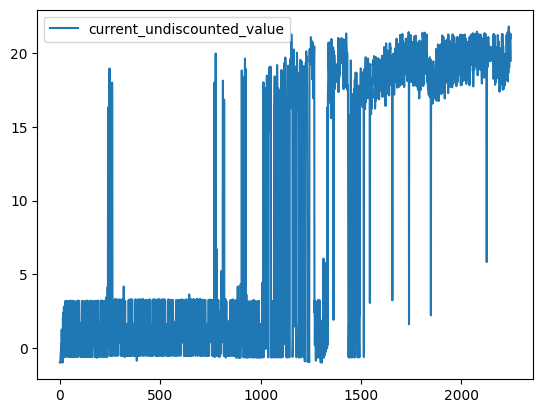

In [25]:
tmp_df = df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "learning_starts", "phase"]]
tmp_df = tmp_df[np.invert(np.logical_and(tmp_df.phase == "train", tmp_df.step_id <= tmp_df.learning_starts))]
g = tmp_df.groupby("iteration_id").last()
g = g.reset_index()
g.iteration_id = g.reset_index().index
g.plot(y="current_undiscounted_value")
g.set_index("iteration_id")

In [26]:
# df = df.reset_index().set_index(["controller", "category", "buffer_size", "task_name"])
# df[df.running_objective == 10].loc[['SAC']]

<Axes: xlabel='iteration_id'>

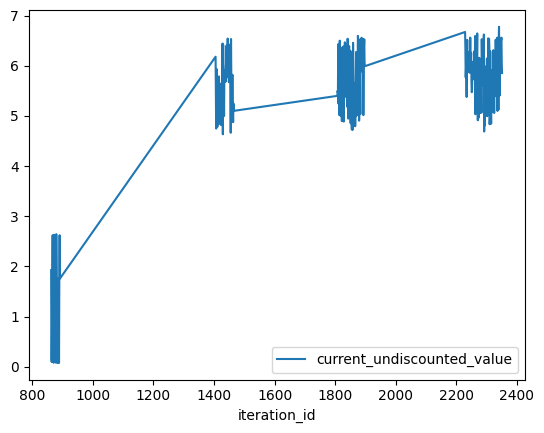

In [27]:
df = df.reset_index().set_index(["controller", "category", "buffer_size", "task_name"])
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index]

tmp_group_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "phase"]].groupby("iteration_id")
tmp_group_df = tmp_group_df.aggregate({
    "current_undiscounted_value": "mean", 
    "task_name": "last",
    "step_id": "last",
    "phase": "last"
    })
tmp_group_df[tmp_group_df.phase=="eval"].plot(y="current_undiscounted_value")

In [28]:
# check_df = tmp_df[tmp_df.phase == "eval"]

# for iter in check_df.iteration_id.unique():
#     t_df = check_df[check_df.iteration_id == iter]
#     t_df.plot(x="step_id", y="current_undiscounted_value", title=f"{t_df.task_name.values[0]} - {t_df.iteration_id.values[0]}")

In [29]:
[c for c in check_df.columns]

['controller',
 'category',
 'buffer_size',
 'index',
 'time',
 'running_objective',
 'current_value',
 'current_undiscounted_value',
 'episode_id',
 'iteration_id',
 'task_name',
 'step_id',
 'phase',
 'exploration',
 'robot_position',
 'Linear Velocity [m/s]',
 'Angular Velocity [rad/s]',
 'Image pixel 0',
 'Image pixel 1',
 'Image pixel 2',
 'Image pixel 3',
 'Image pixel 4',
 'Image pixel 5',
 'Image pixel 6',
 'Image pixel 7',
 'Image pixel 8',
 'Image pixel 9',
 'Image pixel 10',
 'Image pixel 11',
 'Image pixel 12',
 'Image pixel 13',
 'Image pixel 14',
 'Image pixel 15',
 'Image pixel 16',
 'Image pixel 17',
 'Image pixel 18',
 'Image pixel 19',
 'Image pixel 20',
 'Image pixel 21',
 'Image pixel 22',
 'Image pixel 23',
 'Image pixel 24',
 'Image pixel 25',
 'Image pixel 26',
 'Image pixel 27',
 'Image pixel 28',
 'Image pixel 29',
 'Image pixel 30',
 'Image pixel 31',
 'Image pixel 32',
 'Image pixel 33',
 'Image pixel 34',
 'Image pixel 35',
 'Image pixel 36',
 'Image pixel 3

In [30]:
check_df = tmp_df[tmp_df.phase == "eval"]

t_df = check_df[check_df.iteration_id == 900]

def plot_eval(df, title):
    plt.figure(figsize=(12, 6))
    ax1 = plt.subplot(1, 2, 1)
    ax1.set_ylabel("Accumulated reward")
    df.plot(x="step_id", y="current_undiscounted_value", title=title, ax=ax1)

    ax2 = plt.subplot(2, 2, 2)
    df.plot(x="time", 
            y="Linear Velocity [m/s]", ax=ax2, color="tab:orange", title="Linear velocity")

    ax3 = plt.subplot(2, 2, 4)
    df.plot(x="time", 
            y="Angular Velocity [rad/s]", ax=ax3, color="tab:blue", title="Angular velocity")

    plt.tight_layout()


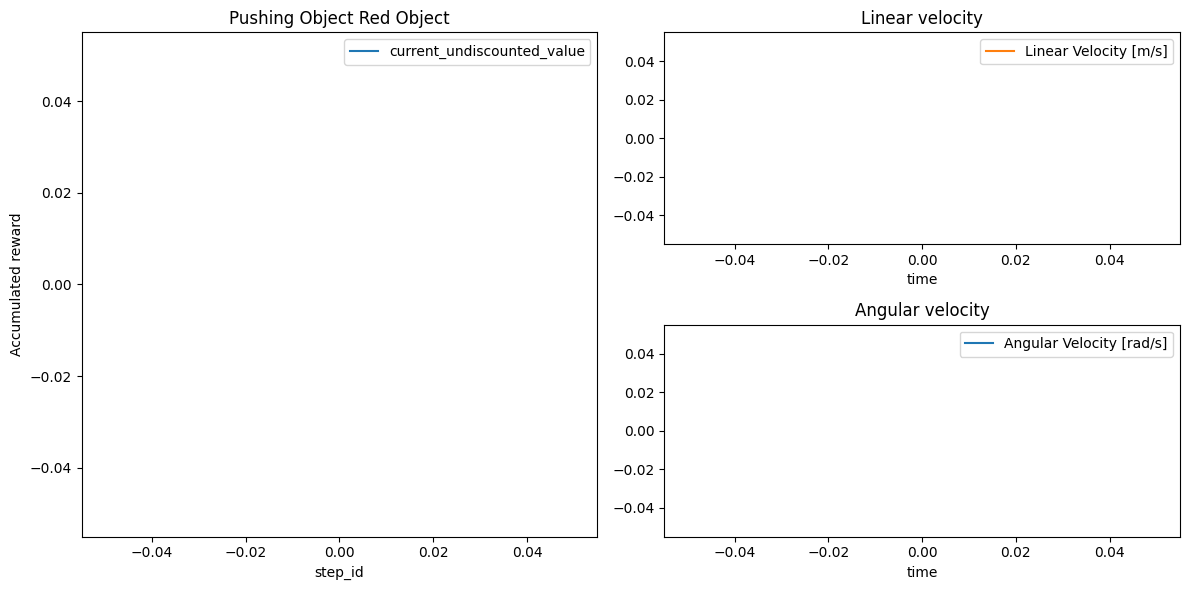

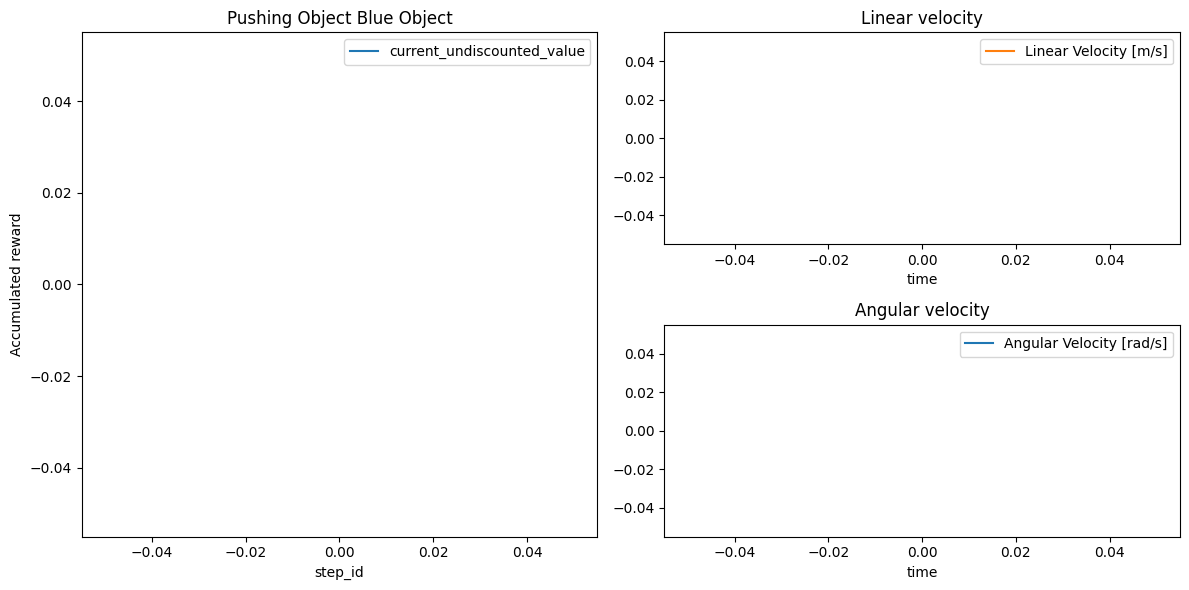

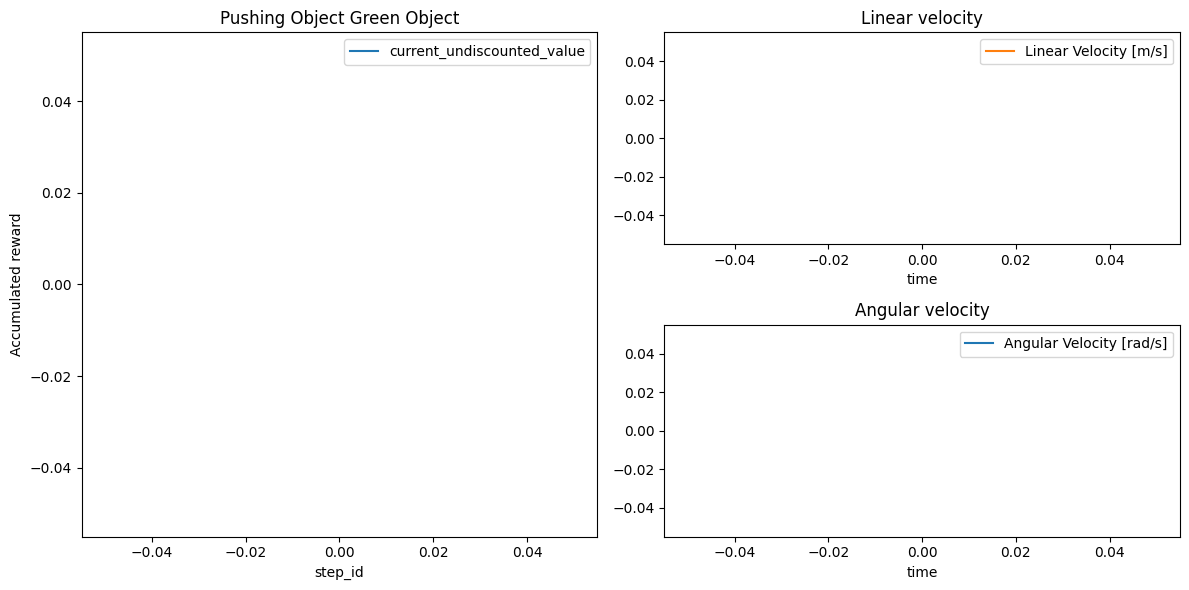

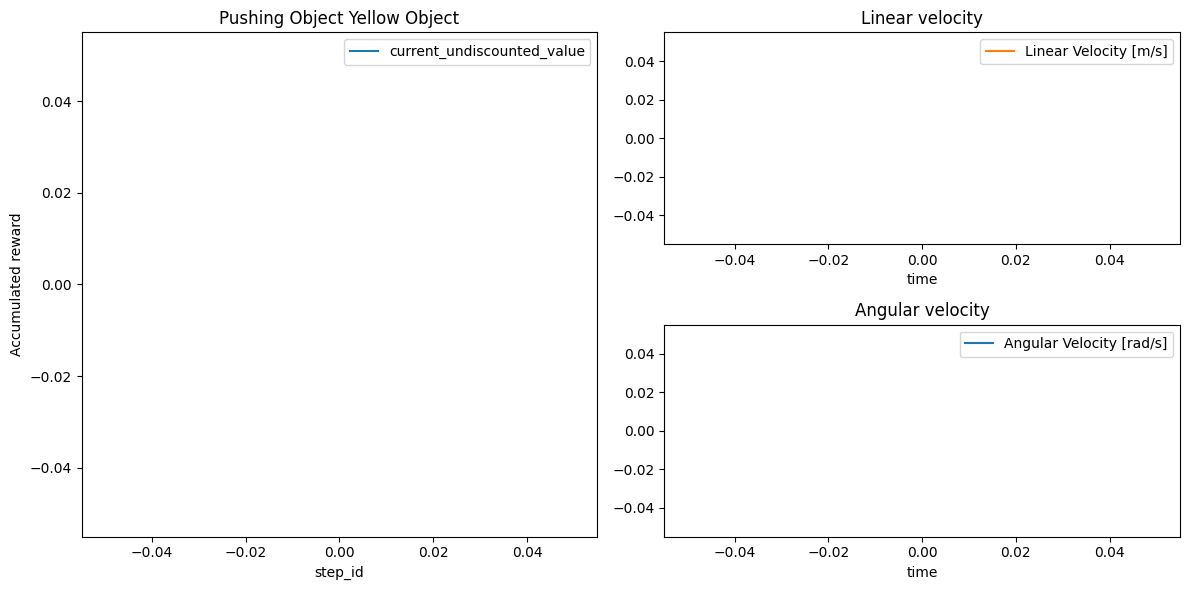

In [31]:
plot_eval(check_df[check_df.iteration_id == 1], title="Pushing Object Red Object")
plot_eval(check_df[check_df.iteration_id == 903], title="Pushing Object Blue Object")
plot_eval(check_df[check_df.iteration_id == 907], title="Pushing Object Green Object")
plot_eval(check_df[check_df.iteration_id == 913], title="Pushing Object Yellow Object")

In [32]:
t_df

,,,task_name,level_0,index,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,step_id,...,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path,is_reset_buffer,learning_starts,trained_task,catch_the_line
controller,category,buffer_size,,,,,,,,,,,,,,,,,,,,,


In [33]:
check_df

task_name  level_0  index   time  \
controller category     buffer_size                                           
SAC        RobotPursuit 20000               red_cube     5000      0  0.000   
                        20000               red_cube     5001      1  0.000   
                        20000               red_cube     5002      2  0.165   
                        20000               red_cube     5003      3  0.330   
                        20000               red_cube     5004      4  0.495   
...                                              ...      ...    ...    ...   
                        20000        yellow_cylinder    24343     10  1.485   
                        20000        yellow_cylinder    24344     11  1.650   
                        20000        yellow_cylinder    24345     12  1.815   
                        20000        yellow_cylinder    24346     13  2.046   
                        20000        yellow_cylinder    24347     14  2.211   

                                     running_objective current_value  \
controller category     buffer_size                                    
SAC        RobotPursuit 20000                 0.535294          None   
                        20000                 0.800000          None   
                        20000                 0.900000          None   
                        20000                 0.450000          None   
                        20000                 0.200000          None   
...                                                ...           ...   
                        20000                 0.966667          None   
                        20000                 0.621053          None   
                        20000                 0.749275          None   
                        20000                 0.910204          None   
                        20000                10.000000          None   

                                     current_undiscounted_value  episode_id  \
controller category     buffer_size                                           
SAC        RobotPursuit 20000                          0.535294           1   
                        20000                          1.335294           1   
                        20000                          2.235294           1   
                        20000                          2.685294           1   
                        20000                          2.885294           1   
...                                                         ...         ...   
                        20000                          7.226024           1   
                        20000                          7.847077           1   
                        20000                          8.596352           1   
                        20000                          9.506556           1   
                        20000                         19.506556           1   

                                     iteration_id  step_id  ...  \
controller category     buffer_size                         ...   
SAC        RobotPursuit 20000                 862        0  ...   
                        20000                 862        1  ...   
                        20000                 862        2  ...   
                        20000                 862        3  ...   
                        20000                 862        4  ...   
...                                           ...      ...  ...   
                        20000                2351      461  ...   
                        20000                2351      462  ...   
                        20000                2351      463  ...   
                        20000                2351      464  ...   
                        20000                2351      465  ...   

                                    Image pixel 1197  Image pixel 1198  \
controller category     buffer_size                                      
SAC        RobotPursuit 20000 

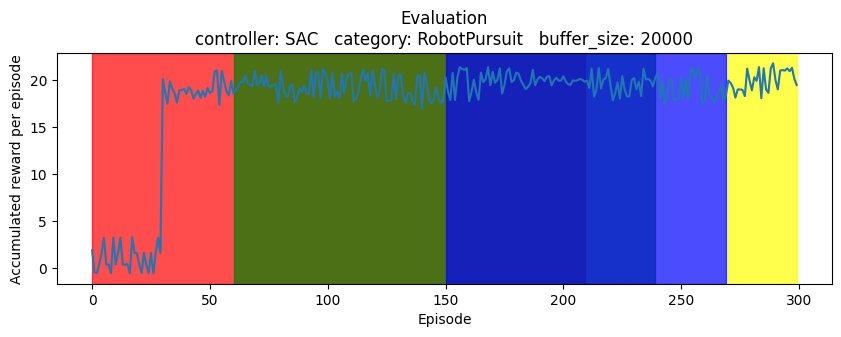

In [34]:
for id in group_df.index:
    plot_learning_curve(id, group_df.index.names, df[df.phase=="eval"], title="Evaluation")

In [35]:
# # df = df.reset_index()
# pixel_columns = [c for c in df.columns if "pixel" in c.lower()]
# chosen_state = np.array(df.loc[:, pixel_columns].iloc[-1])
# im = chosen_state.reshape((20, 20, 3))
# # im = chosen_state.reshape((20, 20, 3))

# plt.imshow(im)

In [36]:
import math

def linefollowing_obj(observation):
    truncated = False

    gray_img = observation.mean(axis=2) ;
    c = observation.shape[1] ;
    black_mask = (gray_img[0,:] < 0.1) ;

    if black_mask.astype(np.int32).sum() < 1: # no black pixels visible
        terminated = True
        return -1.

    x_indices = np.linspace(0.,c,c) ;
    black_indices = x_indices[black_mask] ;
    left_line_index = np.min(black_indices) ;
    
    ret = 1.- math.fabs(left_line_index-c//2) / (c//2) ;

    terminated = ret < 0.
    return ret

In [37]:
from notebooks.check_model import Actor
import torch

checkpoint_path = "notebooks/actor"
actor = Actor(dim_observation=2*50*3*3, dim_action=2, action_bounds=np.array([[0.2, 0.2],[-1.57, 1.57]]))
actor.load_state_dict(torch.load(checkpoint_path))
# actions, _, _ = actor.get_action(torch.Tensor(obs))

class Robot3PiLineFollowing(object):
    def glue_images(self, img):
        if self.step_count == 0:
          self.img0 = self.img1 = img ;
        elif self.step_count == 1:
          self.img0 = self.img1 ;
          self.img1 = img ;
        ret = np.concatenate([self.img0,self.img1,img]) ;
        self.img0 = self.img1 ; self.img1 = img ;
        return ret ;
    
    def get_observation(self, **kwargs):
        return self.glue_images(self.state)

/tmp/ipykernel_8420/338714258.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  actor.load_state_dict(torch.load(checkpoint_path))


FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/actor'

In [ ]:
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[('SAC', 'LineFollowing', 16000)]
tmp_df = tmp_df[tmp_df.iteration_id == 500]
# tmp_df = tmp_df[tmp_df.iteration_id == 700]
# tmp_df = tmp_df[tmp_df.iteration_id == 300]
# tmp_df = tmp_df[tmp_df.iteration_id == 200]
# fig, ax = plt.subplots(len(tmp_df), figsize=(8, 10))
fig, ax = plt.subplots(len(tmp_df), figsize=(15, 15))

brightness_cal = lambda image: np.mean(0.299 * image[:, :, 2] + 0.587 * image[:, :, 1] + 0.114 * image[:, :, 0])

lf_object = Robot3PiLineFollowing()
for i, (_, s) in enumerate(tmp_df.iterrows()):
    pixel_columns = [c for c in s.index if "pixel" in c.lower()]
    im = np.array(s.loc[pixel_columns].dropna()).reshape((2, 50, 3)).astype(float)

    reward = np.round(linefollowing_obj(im), 2)
    
    # Only apply for Blue image: inscrease brightness
    if im.mean(axis=1).sum(axis=0).argmax() == 2:
        alpha = 1.0
        beta = 32 / 255
        im = im * alpha + beta

    lf_object.state = im
    lf_object.step_count = i
    observation = torch.Tensor(lf_object.get_observation().flatten().reshape((1, -1)))

    action = actor.get_action(observation)[0].detach().numpy()
    angular = np.round(action[0, 1], 2)
    # print()
    ax[i].imshow(im)
    ax[i].set_title("{}: {} : {} : {}".format(i, reward, "left" if angular > 0 else "right", angular))
    ax[i].axis("off")

plt.tight_layout()

In [ ]:
im.mean(axis=1).sum(axis=0).argmax()

In [ ]:
np.histogram(observation[0])

Red: (array([756,   2,   3,   3,   6,   5,   4,   9,   7, 105]),
 array([0.1254902 , 0.17215687, 0.21882354, 0.2654902 , 0.3121569 ,
        0.35882354, 0.40549022, 0.45215687, 0.49882355, 0.5454902 ,
        0.5921569 ], dtype=float32))

In [ ]:
# from src.objective import RobotPursuitRunningObjective

# objective_func = RobotPursuitRunningObjective()

# objective_func(state=im, 
#                catcher_pos=[1, 1], 
#                runner_pos=[0, 0], 
#                action=[1, 0], 
#                step_count=0, 
#                max_steps_per_episode=100,
#                runner_collision_thickness=0.49,
#                arena_bounds=[-2.5,2.5,-2.5,2.5],
#                info={})

In [ ]:
import numpy as np
np.sum(im)

In [ ]:
plot_learning_curve(('SAC', 'LineFollowing', False), group_df.index.names, df)
plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)

In [ ]:
tmp_df["previous_step"] = [tmp_df.step_id.values.tolist()[0]] + tmp_df.step_id.values.tolist()[:-1]
tmp_df[(tmp_df.step_id.diff() < 0)]
# tmp_df.step_id.values.tolist()[1:]+ [tmp_df.step_id.values.tolist()[-1]]

In [ ]:
tmp_df[tmp_df.iteration_id == 1196]